# Principal Component Analysis of Raman Spectra

## Setup

Import required packages

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import brokenaxes as bax

from matplotlib import style
from sklearn.decomposition import PCA

from raman_lib.preprocessing import (BaselineCorrector,
                                     RangeLimiter,
                                     SavGolFilter,
                                     Normalizer)

from raman_lib.misc import load_data

style.use("default")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

Settings

In [52]:
# Path where the data is stored
data_path = r"./data/Trico_Vergleich_Beregnung/Gesamt"

# Spectral range/ranges to analyze
# Format: [Start, End, Start2, End2, ...]
# Use 'None' as the first or last value to use the whole range
wn_limits = [400, 480, 580, 680, 1000, 1120, 1230, 1350, 1400, 1500, 2800, 3000]

# Window size for smoothing the spectra
# Higher means stronger smoothing
sg_window = 25

In [53]:
data = load_data(data_path)

labels = data["label"].str.extract("(.)(\d)")
y1, y2 = labels[0], labels[1]

if "file" in data.columns:
    X = data.drop(columns=["label", "file"])
else:
    X = data.drop(columns=[""])
wns = np.asarray(X.columns.astype(float))
X = np.asarray(X)

y1, y1_key = pd.factorize(y1, sort=True)
y2, y2_key = pd.factorize(y2, sort=True)

y2_key = pd.Index(["Unbehandelt", "Beregnet 2h", "Beregnet 4h", "Beregnet 6h", "Nur Behandelt"])

Text(0, 0.5, 'Intensity (-)')

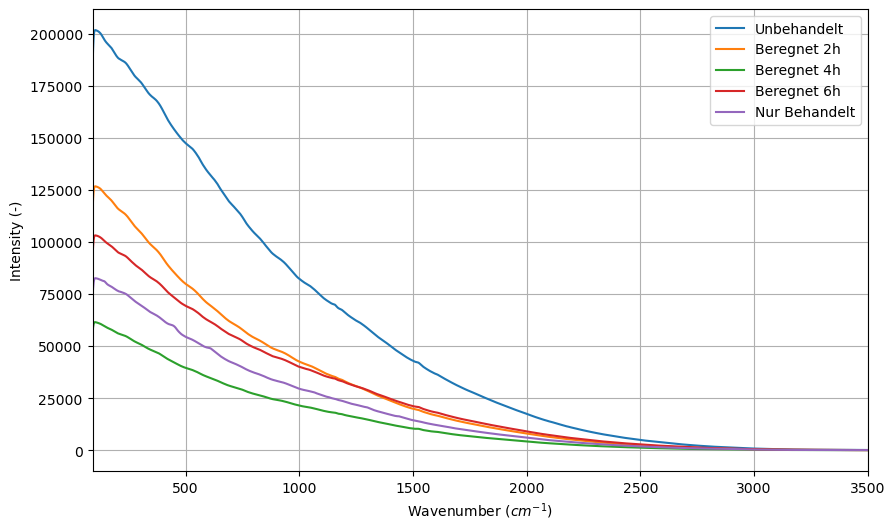

In [54]:
for i in range(len(y2_key)):
    plt.plot(wns, X[y2==i].mean(axis=0), label=y2_key[i])
plt.margins(x=0)
plt.legend()

plt.grid()
plt.xlabel("Wavenumber ($cm^{-1}$)")
plt.ylabel("Intensity (-)")

Text(0, 0.5, 'Intensity (-)')

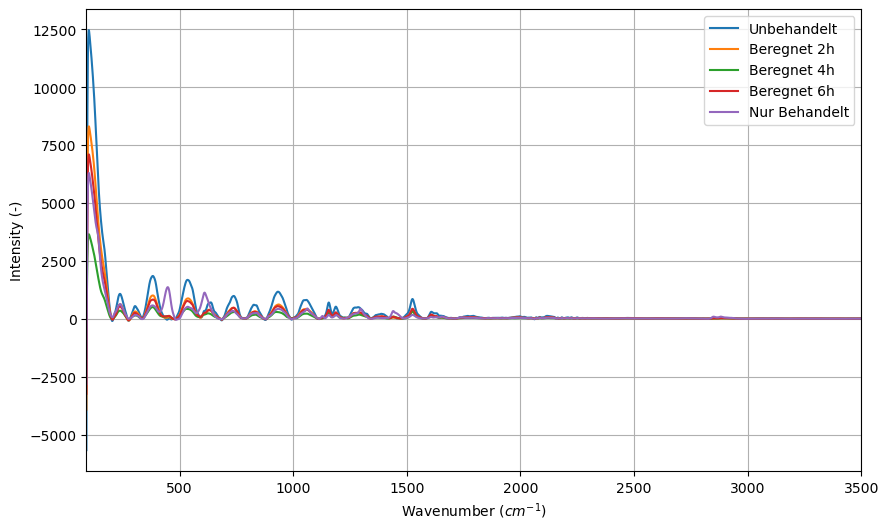

In [55]:
X_bl = BaselineCorrector().fit_transform(X)

for i in range(len(y2_key)):
    plt.plot(wns, X_bl[y2==i].mean(axis=0), label=y2_key[i])
plt.margins(x=0)
plt.legend()

plt.grid()
plt.xlabel("Wavenumber ($cm^{-1}$)")
plt.ylabel("Intensity (-)")

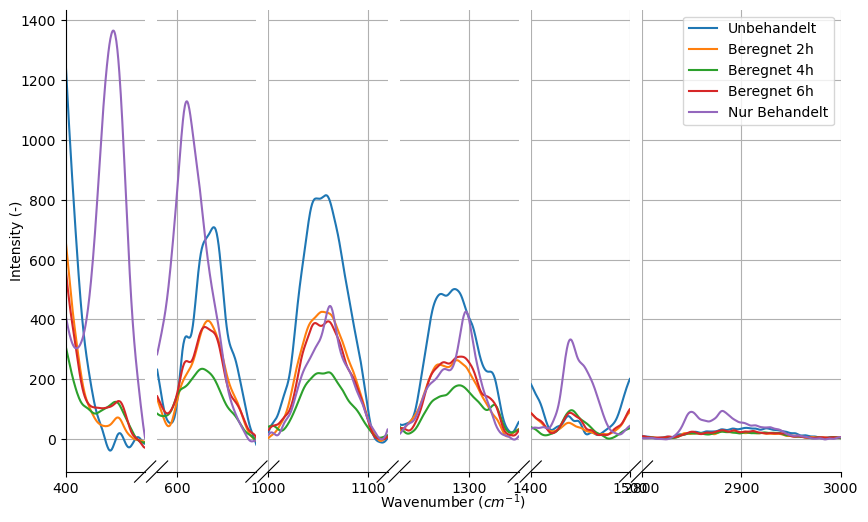

In [56]:
rl = RangeLimiter(lim=wn_limits, reference=wns)
X_rl = rl.fit_transform(X_bl)
wns_reduced = np.concatenate([wns[l0:l1] for l0, l1 in zip(rl.lim_[::2], rl.lim_[1::2])])

fig = plt.figure()
ax = bax.brokenaxes(xlims=tuple(zip(rl.lim[::2], rl.lim[1::2])), wspace=0.1)

for i in range(len(y2_key)):
    ax.plot(wns_reduced, X_rl[y2==i].mean(axis=0), label=y2_key[i])

ax.legend()
ax.set_xlabel("Wavenumber ($cm^{-1}$)")
ax.set_ylabel("Intensity (-)")
_ = ax.grid()

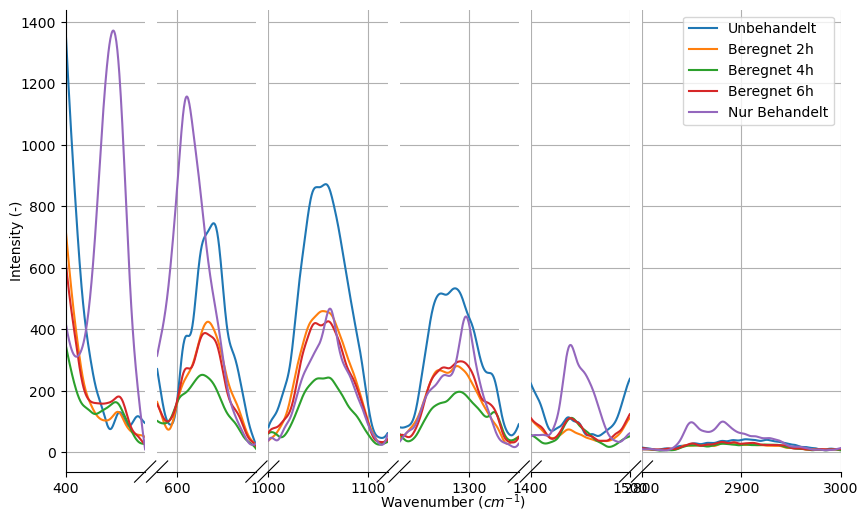

In [57]:
X_smooth = SavGolFilter(window=sg_window, limits=rl.lim_).fit_transform(X_rl)

fig = plt.figure()
ax = bax.brokenaxes(xlims=tuple(zip(rl.lim[::2], rl.lim[1::2])), wspace=0.1)

for i in range(len(y2_key)):
    ax.plot(wns_reduced, X_smooth[y2==i].mean(axis=0), label=y2_key[i])

ax.legend()
ax.set_xlabel("Wavenumber ($cm^{-1}$)")
ax.set_ylabel("Intensity (-)")
_ = ax.grid()

[None, None, None, None, None, None]

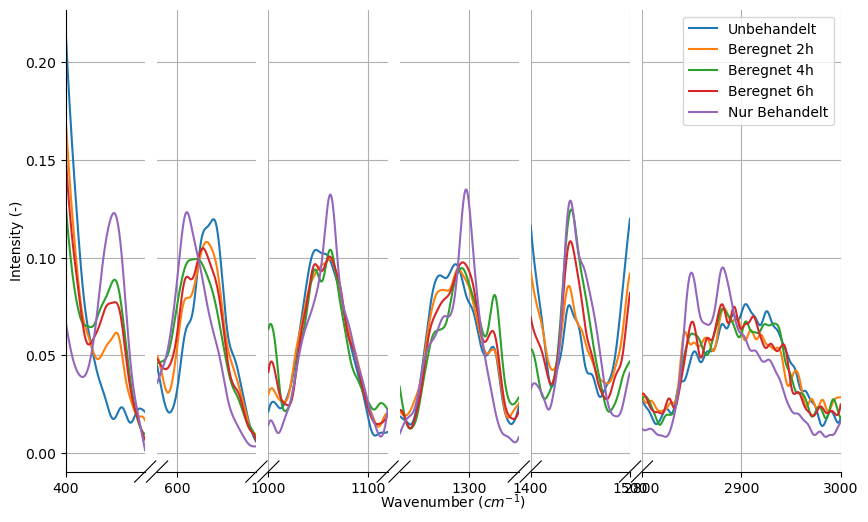

In [74]:
# X_norm = Normalizer().fit_transform(X_smooth)
X_norm = Normalizer(limits=rl.lim_).fit_transform(X_smooth)

fig = plt.figure()
ax = bax.brokenaxes(xlims=tuple(zip(rl.lim[::2], rl.lim[1::2])), wspace=0.1)

for i in range(len(y2_key)):
    ax.plot(wns_reduced, X_norm[y2==i].mean(axis=0), label=y2_key[i])

ax.legend()
ax.set_xlabel("Wavenumber ($cm^{-1}$)")
ax.set_ylabel("Intensity (-)")
ax.grid()

In [75]:
n_components = 5

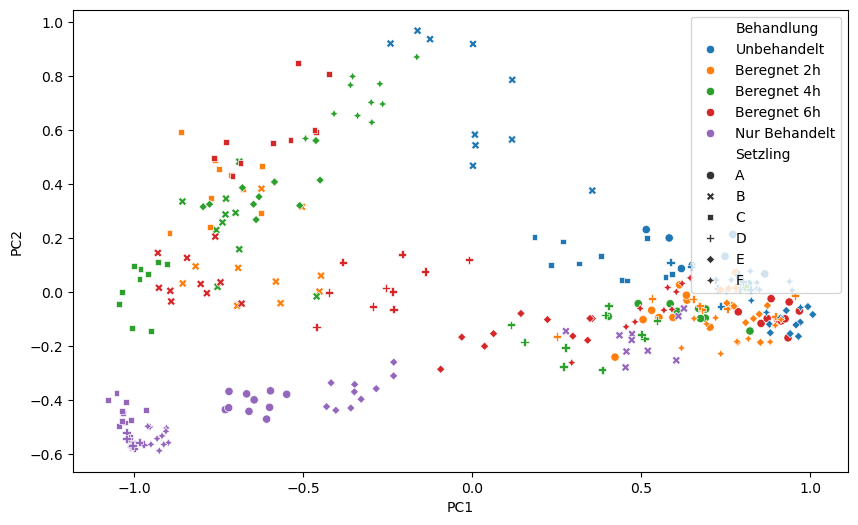

In [76]:
# Run PCA with selected no. of components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_norm)

pca_data = pd.DataFrame(X_pca, columns=[f"PC{i}" for i in range(1, n_components + 1)])

pca_data["Setzling"] = y1_key[y1]
pca_data["Behandlung"] = y2_key[y2]

fig, ax = plt.subplots()

sns.scatterplot(data=pca_data, x="PC1", y="PC2", hue="Behandlung", style="Setzling", ax=ax)
ax.legend(loc="upper right")

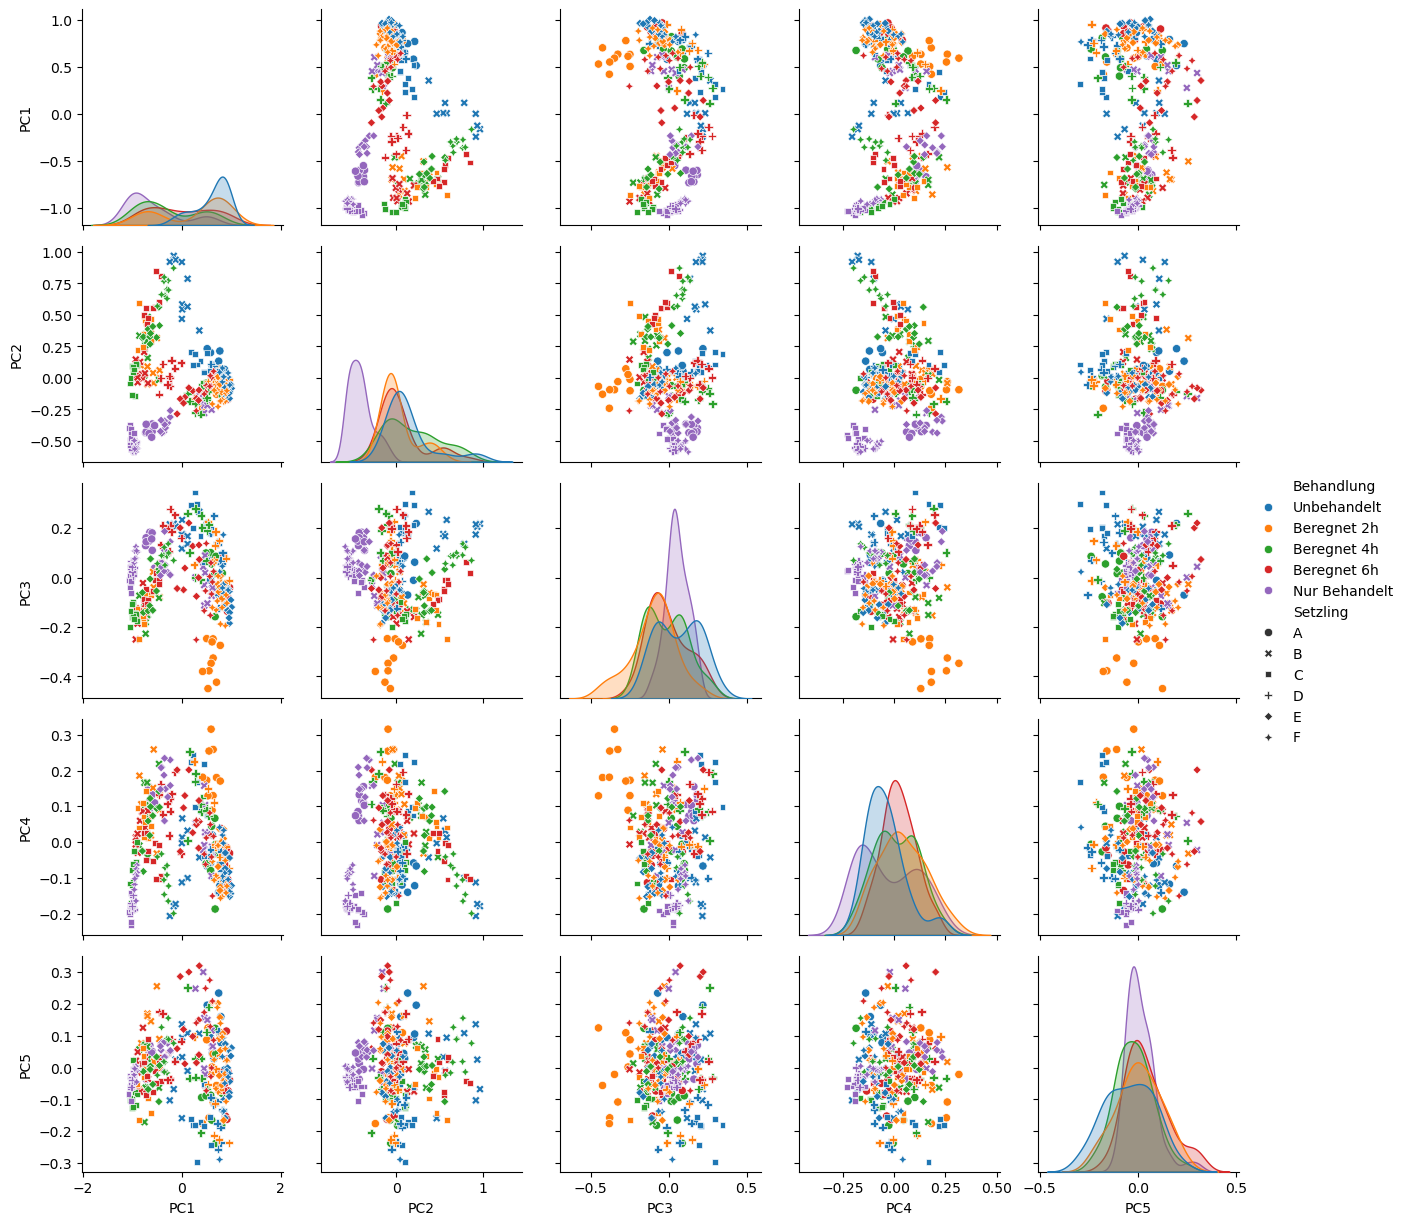

In [77]:
# Pairwise score plot with density plots on the diagonal

grid = sns.PairGrid(pca_data, hue="Behandlung")
grid.map_offdiag(sns.scatterplot,
                 style=pca_data["Setzling"])
grid.map_diag(sns.kdeplot, fill=True)
grid.set()
grid.add_legend(title="")

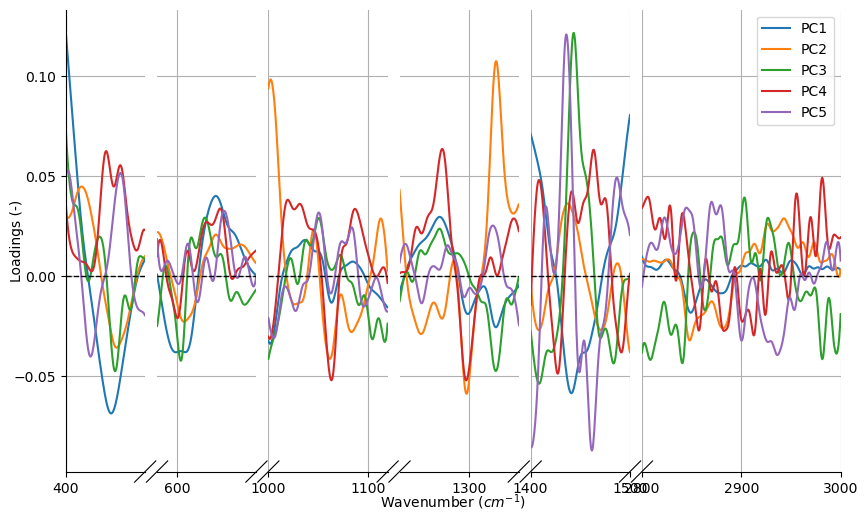

In [78]:
fig = plt.figure()
ax = bax.brokenaxes(xlims=tuple(zip(rl.lim[::2], rl.lim[1::2])), wspace=0.1)

for i, component in enumerate(pca.components_):
    ax.plot(wns_reduced, component, label=f"PC{i+1}")

ax.axhline(y=0, linestyle="--", linewidth=1, color="k")

ax.legend()
ax.set_xlabel("Wavenumber ($cm^{-1}$)")
ax.set_ylabel("Loadings (-)")
_ = ax.grid()